In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pandas as pd

In [4]:
data=pd.read_csv('sentiment.csv')
# ajouter les nom des colonne comme premiere ligne du fichier csv
data

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
...,...,...,...,...
74676,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74677,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74678,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74679,9200,Nvidia,Positive,Just realized between the windows partition of...


In [5]:
columns=['numero','societe','target','phrase']
data.columns=columns
data
data=data.drop(['numero','societe'],axis=1)
data

,target,phrase
0,Positive,I am coming to the borders and I will kill you...
1,Positive,im getting on borderlands and i will kill you ...
2,Positive,im coming on borderlands and i will murder you...
3,Positive,im getting on borderlands 2 and i will murder ...
4,Positive,im getting into borderlands and i can murder y...
...,...,...
74676,Positive,Just realized that the Windows partition of my...
74677,Positive,Just realized that my Mac window partition is ...
74678,Positive,Just realized the windows partition of my Mac ...
74679,Positive,Just realized between the windows partition of...


# mon objectif est de faire l'analyse de phrase et voir c'est positif negatif etc
## vue que la machine ne connait que des chiffres je dois trouver un moyen de transformer les données en chiffres.
### chaque mots doit etre des token et on vas lui donnees un chiffre
### Ensuite une dictionnaire est cree
### on recupere la taille du dictionnaire qui sera input dim de notre model pour le embedding
### apres avoir fait tous ça , l'entree de notre reseau de neuronne devrons etre les memes par ce que chaque phrase a des taille differentes, en faisant ce qu'on appele pad_sequences.
### la sortie de neuronne doit avoir la taille de notre etiquette ensuite une fonction activation sigmoid pour binary et softmax pour plusieur class , on utilisateur l'accuracy 
### le model utilise est SimpleRNN

In [6]:
data['phrase']=data['phrase'].str.lower()
data['target']=data['target'].str.lower()
data

,target,phrase
0,positive,i am coming to the borders and i will kill you...
1,positive,im getting on borderlands and i will kill you ...
2,positive,im coming on borderlands and i will murder you...
3,positive,im getting on borderlands 2 and i will murder ...
4,positive,im getting into borderlands and i can murder y...
...,...,...
74676,positive,just realized that the windows partition of my...
74677,positive,just realized that my mac window partition is ...
74678,positive,just realized the windows partition of my mac ...
74679,positive,just realized between the windows partition of...


In [7]:
X=data['phrase'].values
y=data['target'].values
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
# Parce que la machine ne connait que des chiffres je dois trouver un moyen de transformer les données en chiffres.
# chaque mots doit etre des token et on vas lui donnees un chiffre
# astype pour convertir en string sinon il y a des erreur lors de la tokenisation
x_train=x_train.astype(str)
x_test=x_test.astype(str)
tk=Tokenizer()
tk.fit_on_texts(x_train)
vocab_size=len(tk.word_index)+1
print(vocab_size, 'index et word', tk.word_index)

32262 index et word {'the': 1, 'i': 2, 'to': 3, 'and': 4, 'a': 5, 'of': 6, 'is': 7, 'in': 8, 'for': 9, 'this': 10, 'it': 11, 'on': 12, 'you': 13, 'my': 14, 'that': 15, 'com': 16, 'with': 17, 'game': 18, 'so': 19, 'be': 20, 'me': 21, 'just': 22, 'have': 23, 'but': 24, 'not': 25, 'are': 26, 'at': 27, 'all': 28, 'was': 29, 'like': 30, 'out': 31, 'from': 32, '2': 33, 'your': 34, 'pic': 35, 'twitter': 36, 'now': 37, 'get': 38, 'we': 39, 'as': 40, 'they': 41, 'one': 42, 'has': 43, 'if': 44, 't': 45, 'do': 46, 'about': 47, 'good': 48, 'can': 49, 'play': 50, 'no': 51, 'will': 52, 'an': 53, 'really': 54, 'new': 55, 'up': 56, 'love': 57, 'when': 58, "i'm": 59, 'unk': 60, 'what': 61, 'more': 62, 'by': 63, 'time': 64, 'how': 65, 'johnson': 66, 'or': 67, 'some': 68, 'people': 69, 'why': 70, '3': 71, 'see': 72, 'shit': 73, 'co': 74, "it's": 75, 'been': 76, 'best': 77, 'facebook': 78, 'still': 79, '’': 80, 'games': 81, 'https': 82, 'got': 83, 'go': 84, 'amazon': 85, '1': 86, 'great': 87, 'even': 88, 

In [9]:
# je dois transformer mes phrases en sequences de tokens notre matrice 
sequences = tk.texts_to_sequences(x_train)
print(sequences[:5])

[[14, 2593, 10715, 29, 19, 628, 27, 21, 9, 319, 31, 6, 273, 3753, 5, 8380, 6, 258, 3864, 4, 821, 3864], [2, 577, 217, 15, 9, 163, 851, 6, 138, 2, 23, 27, 679, 11, 5552, 21, 27, 641, 4124, 605, 6, 5271], [451, 9094, 66, 25485, 66, 451, 4654, 150, 1494, 6203, 4, 4821, 9094, 7160, 3332, 27, 16, 150, 1102, 2454, 133], [71, 139, 104, 11, 143, 7, 40, 2, 251, 511, 1, 18533, 14136, 3754, 12, 4655, 4278, 196, 45, 20, 10716], [27, 1, 239, 64, 684, 1, 434, 15, 104, 26, 549, 68, 265, 499, 69, 743, 629, 1, 982, 466, 147, 6, 97, 46, 25, 23, 316, 3, 313, 518, 4, 46, 25, 23, 316, 3, 313, 281, 241, 147, 6, 97, 46, 25, 23, 316, 3, 313, 281]]


In [10]:
# Vue que chaque phrase a des taille differentes, en faisant ce qu'on appele pad_sequences.
max_len=max(len(i) for i in sequences)
print('max length', max_len)
input_data=pad_sequences(sequences,maxlen=max_len,padding='post')
print(input_data[:5])

max length 166
[[   14  2593 10715    29    19   628    27    21     9   319    31     6
    273  3753     5  8380     6   258  3864     4   821  3864     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0    

In [11]:
# Maintenant je dois faire la meme chose pour le test set
test_sequences=tk.texts_to_sequences(x_test)
test_data=pad_sequences(test_sequences,maxlen=max_len,padding='post')
print(test_data[:5])

[[  424     3    84     8 20537  1083     3   369   181  2257    29  1976
   8258    56   854     6   689     3   211   291   181  4387  3497     3
     72     5 30073   734    67   232    24    51   118    29    89   205
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0 

In [12]:
# Encode les labeles
le=LabelEncoder()
y_train=le.fit_transform(y_train)
y_test=le.transform(y_test)
print(le.classes_)
list(le.inverse_transform([0,1,2,3]))

['irrelevant' 'negative' 'neutral' 'positive']


['irrelevant', 'negative', 'neutral', 'positive']

In [13]:
# Maintenant je vais faire la machine learning
model=keras.Sequential(
    [ 
        keras.layers.Embedding(input_dim=vocab_size,output_dim=16,input_length=max_len),
        keras.layers.SimpleRNN(32),
        keras.layers.Dense(len(le.classes_),activation='softmax')
     ]
)
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.summary()

c:\Users\hp\Desktop\tous\ML\env\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
history=model.fit(input_data,y_train,validation_data=(test_data,y_test),epochs=10)

Epoch 1/10
1867/1867 ━━━━━━━━━━━━━━━━━━━━ 53s 27ms/step - accuracy: 0.2977 - loss: 1.3681 - val_accuracy: 0.2995 - val_loss: 1.3691
Epoch 2/10
1867/1867 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.2988 - loss: 1.3683 - val_accuracy: 0.2993 - val_loss: 1.3681
Epoch 3/10
1867/1867 ━━━━━━━━━━━━━━━━━━━━ 57s 31ms/step - accuracy: 0.2981 - loss: 1.3682 - val_accuracy: 0.2860 - val_loss: 1.3684
Epoch 4/10
1867/1867 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.3045 - loss: 1.3646 - val_accuracy: 0.3602 - val_loss: 1.3406
Epoch 5/10
1867/1867 ━━━━━━━━━━━━━━━━━━━━ 66s 36ms/step - accuracy: 0.4107 - loss: 1.2830 - val_accuracy: 0.4694 - val_loss: 1.2142
Epoch 6/10
1867/1867 ━━━━━━━━━━━━━━━━━━━━ 63s 34ms/step - accuracy: 0.5223 - loss: 1.1273 - val_accuracy: 0.5090 - val_loss: 1.1538
Epoch 7/10
1867/1867 ━━━━━━━━━━━━━━━━━━━━ 68s 37ms/step - accuracy: 0.5738 - loss: 1.0309 - val_accuracy: 0.5309 - val_loss: 1.1334
Epoch 8/10
1867/1867 ━━━━━━━━━━━━━━━━━━━━ 65s 35ms/step - accuracy: 0.6031 -

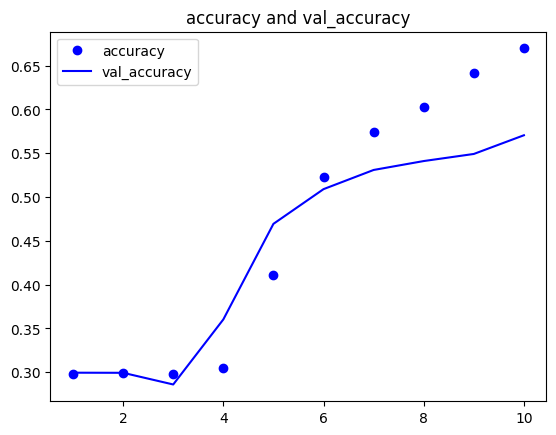

In [15]:
accuracy=history.history['accuracy']
val_accuracy=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']
epochs=range(1,len(accuracy)+1)
plt.plot(epochs,accuracy,'bo',label='accuracy')
plt.plot(epochs,val_accuracy,'b',label='val_accuracy')
plt.title('accuracy and val_accuracy')
plt.legend()

In [16]:
evaluation=model.evaluate(test_data,y_test)
print('test loss', evaluation[0])
print('test accuracy', evaluation[1])

467/467 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5705 - loss: 1.0818
test loss 1.0818241834640503
test accuracy 0.570529580116272


In [17]:
def predict_sentiment(text):
    text=text.lower()
    sequence=tk.texts_to_sequences([text])
    padded=pad_sequences(sequence,maxlen=max_len,padding='post')
    pred=model.predict(padded)
    label=np.argmax(pred,axis=1)[0]
    print('la phrase: ', text ,'est de type',le.inverse_transform([label])[0])

In [35]:
predict_sentiment('I dislike this product')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
la phrase:  i dislike this product est de type neutral


In [36]:
model.save('sentiment_model.keras')


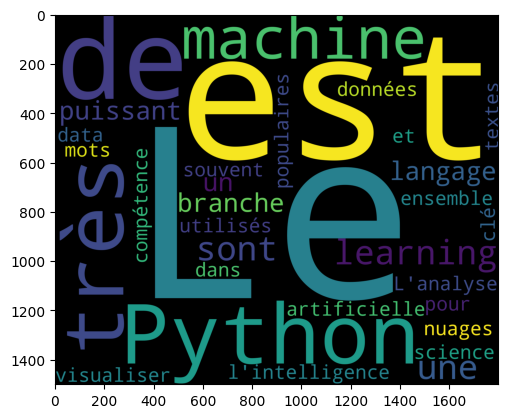

In [25]:
import wordcloud as wc
text=' '.join(data['phrases'])
wordcloud=wc.WordCloud(width=1800,height=1500).generate(text)
plt.imshow(wordcloud)

In [41]:
model = keras.models.load_model('sentiment_model.keras')
model.summary()

c:\Users\hp\Desktop\tous\ML\env\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 6 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (1, 4)                 │           668 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,006 (7.84 KB)

 Trainable params: 668 (2.61 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,338 (5.23 KB)